# Generating the Initial DataFrame 

In this notebooks we generate a dataframe from the excel document containing the thickness and we iterate over the folder with the spectrum samples in _.txt_ format. In this first notebook we process 101 samples.

## Used libraries

In [1]:
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np

## Experimental Samples

The thickness for each thin layer has been characterized, their values are in a _.csv_ file.

In [2]:
# Excel 
excel_data = pd.read_csv('../../experimental_samples/Processed_Data/Thickness-Order-100-1600-3.csv', index_col= 0)
excel_data.shape

(101, 5)

In [3]:
excel_data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000
1,ANZO01-1,ANZO011M,141.565084,18.100000,10.925087
2,ANZO30,ANZO30M,167.256504,21.600000,10.256410
3,ANZO35,ANZO35M,167.777276,21.100000,9.990530
4,AZO3Min2,AZO3Mi2M,224.029336,8.740362,3.166683


In [4]:
# Eliminate the difference between upper and lower case
excel_data['Nombre-Arc'] = excel_data['Nombre-Arc'].str.upper()

## Histograms

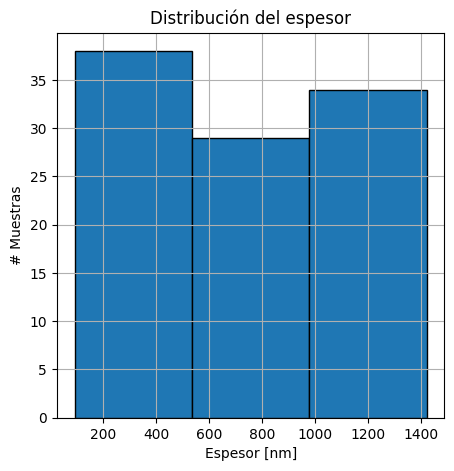

In [5]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 3, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin3.png')
plt.show()

Bin edges: [  91.22378737  534.74796977  978.27215217 1421.79633456]
Bin size: [443.5241824 443.5241824 443.5241824]


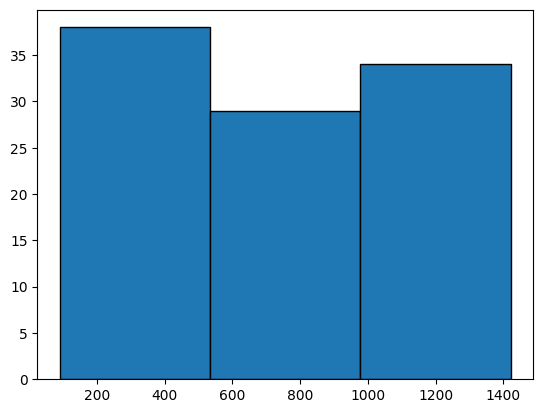

In [6]:
counts, bin_edges, patches = plt.hist(excel_data['Espesor'], bins=3, edgecolor='black')
print("Bin edges:", bin_edges)
print("Bin size:", np.diff(bin_edges))

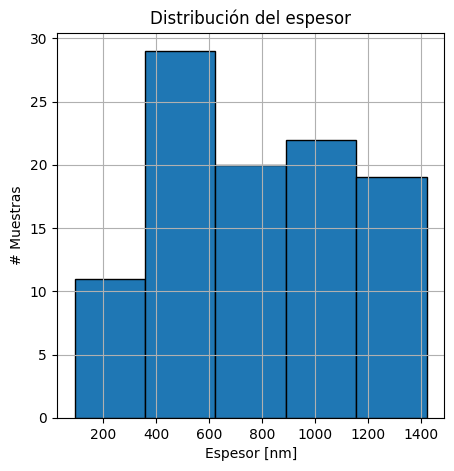

In [7]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 5, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin5.png')
plt.show()

Bin edges: [  91.22378737  357.33829681  623.45280625  889.56731569 1155.68182513
 1421.79633456]
Bin size: [266.11450944 266.11450944 266.11450944 266.11450944 266.11450944]


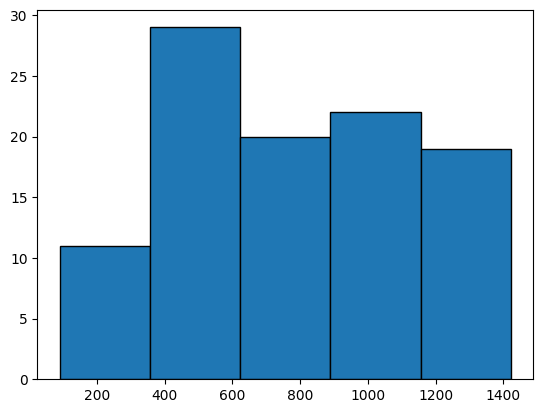

In [8]:
counts, bin_edges, patches = plt.hist(excel_data['Espesor'], bins=5, edgecolor='black')
print("Bin edges:", bin_edges)
print("Bin size:", np.diff(bin_edges))

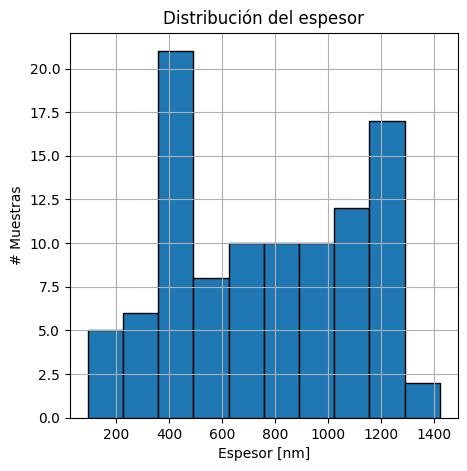

In [9]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 10, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin10.png')
plt.show()

Bin edges: [  91.22378737  224.28104209  357.33829681  490.39555153  623.45280625
  756.51006097  889.56731569 1022.62457041 1155.68182513 1288.73907984
 1421.79633456]
Bin size: [133.05725472 133.05725472 133.05725472 133.05725472 133.05725472
 133.05725472 133.05725472 133.05725472 133.05725472 133.05725472]


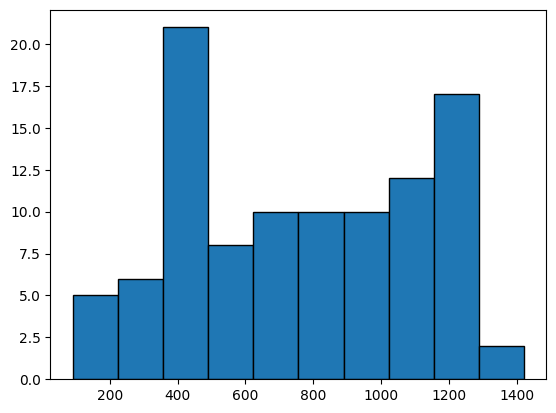

In [10]:
counts, bin_edges, patches = plt.hist(excel_data['Espesor'], bins=10, edgecolor='black')
print("Bin edges:", bin_edges)
print("Bin size:", np.diff(bin_edges))

An interesting plot is the Kernel Density Estimation for the Thickness Distribuion. This result will be key in the future. 

In [11]:
import seaborn as sns

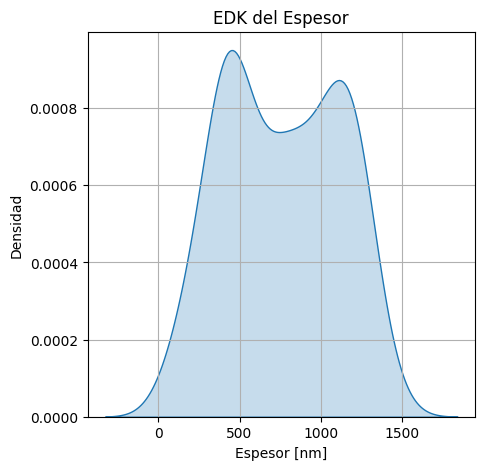

In [12]:
plt.figure(figsize = (5,5))
sns.kdeplot(excel_data['Espesor'], fill='True')
#plt.hist(excel_data['Espesor'], bins = 10, edgecolor = 'black')
plt.title('EDK del Espesor')
plt.grid()
plt.ylabel('Densidad')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/kde.png')
plt.show()

Where the mean and std values for the thickness are:

In [13]:
np.mean(excel_data['Espesor']), np.std(excel_data['Espesor'])

(np.float64(758.7270373606567), np.float64(347.8807732103165))

Let's now focus on the Porcentual Error

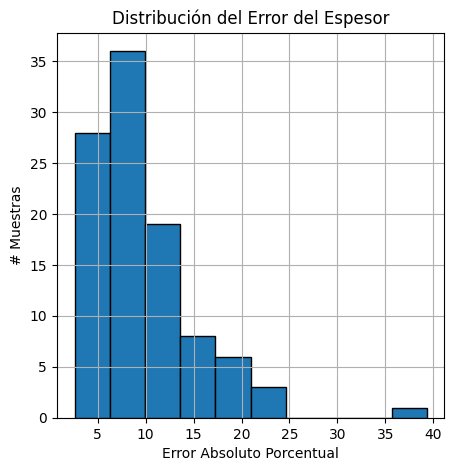

In [14]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Error Porcentual'], bins = 10, edgecolor = 'black')
plt.title('Distribución del Error del Espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Error Absoluto Porcentual')
#plt.savefig('./images/error1.png')
plt.show()

Where the mean and std values are:

In [15]:
np.mean(excel_data['Error Porcentual']), np.std(excel_data['Error Porcentual'])

(np.float64(9.659602685326732), np.float64(5.446962464487553))

In [16]:
#__df = excel_data[ (excel_data['Espesor'] >=500 ) & (excel_data['Espesor'] <=1500)   ] 
__df = excel_data # This section is useful for selecting just an thickness interval
#__df.head()

Now, we iterate over the SpectrumOrder folder, this folder contains all the experimental samples organized by thickness range [100,200] nm.

In [17]:
# Iteracion de las muestras
path_dataset = Path('../../experimental_samples/Spectrum_Order/')
names = []
samples = []
for filename in path_dataset.rglob('*'):
    if filename.suffix == '.txt': 
        try: 
            #print(filename)
            df = np.array(pd.read_csv(filename, sep = ' ', usecols = [0, 1], header = None)[1])
            samples.append(df)
            names.append(filename.name[:-4])
        except Exception as e: 
            print(e)

In [18]:
samples = np.expand_dims( np.array(samples), axis = 2) # Give the correct format 

In [19]:
samples.shape

(101, 911, 1)

In [20]:
len(names), names[:3]

(101, ['ANZO452M', 'ANZO453M', 'ANZO44M'])

In [21]:
_df = pd.DataFrame({
    'Nombre-Arc': names,
    'Espectro': [ [s] for s in samples ]
})

In [22]:
_df.head()

,Nombre-Arc,Espectro
0,ANZO452M,"[[[0.076], [0.154], [0.066], [0.054], [0.066],..."
1,ANZO453M,"[[[0.064], [0.13], [0.046], [0.072], [0.044], ..."
2,ANZO44M,"[[[0.02], [0.093], [0.025], [0.084999], [0.035..."
3,ANZO27M,"[[[0.008], [0.108], [0.036], [0.084], [0.058],..."
4,ANZO26M,"[[[0.105], [0.152], [0.101], [0.118], [0.053],..."


This section outputs the samples in the excel file and the sample in the SpectrumOrder folder. In everything's right the values of unique shall be empty.

In [23]:
unique_in_df1 = __df.loc[~__df['Nombre-Arc'].isin(_df['Nombre-Arc']), 'Nombre-Arc']

In [24]:
unique_in_df2 = _df.loc[~_df['Nombre-Arc'].isin(__df['Nombre-Arc']), 'Nombre-Arc']

In [25]:
unique_in_df1

Series([], Name: Nombre-Arc, dtype: object)

In [26]:
unique_in_df2

Series([], Name: Nombre-Arc, dtype: object)

In [27]:
_df.shape

(101, 2)

In [28]:
# Merge de Datasets 
df_junto = pd.merge(__df, _df, on='Nombre-Arc', how='inner')

In [29]:
df_junto.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO01-1,ANZO011M,141.565084,18.100000,10.925087,"[[[0.037], [0.078], [0.045], [0.092], [0.049],..."
2,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
3,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
4,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."


We've just created a unique DataFrame with the name, thickness, error and spectrum. Let's save it as a Pickle

In [30]:
df_junto.to_pickle('../../results/dataframe_spectrum_thickness_101.pkl')